=== MULAI VERIFIKASI ===
1. Logical Flow Check: PASS (Antrian FIFO berjalan benar)

2. Event Tracing (3 Mahasiswa Pertama):
   id_mahasiswa  mulai_layanan  selesai_layanan  waktu_layanan
0             1       0.000000         1.749080       1.749080
1             2       1.749080         4.650509       2.901429
2             3       4.650509         7.114497       2.463988

3. Extreme Test (N=1, Durasi Tetap 2): Total Waktu = 2.0 (Harusnya 2). Status: PASS
4. Extreme Test (N=10, Durasi Tetap 1): Total Waktu = 10.0 (Harusnya 10). Status: PASS

5. Distribusi Check: Rata-rata sampel = 2.04 (Teori Uniform(1,3) = 2.0). Status: PASS
6. Reproducibility Check: PASS

=== KESIMPULAN VERIFIKASI: MODEL TELAH DIVERIFIKASI ===

=== MULAI VALIDASI ===
1. Face Validation: Hasil simulasi untuk N=30 menghasilkan total waktu ~60 menit.
   Secara logika manusia, jika rata-rata 2 menit/orang x 30 orang = 60 menit. Masuk akal.

2. Validasi Teoritis (N=30):
   Simulasi: 56.32 menit
   Teoritis: 60.00 menit
 

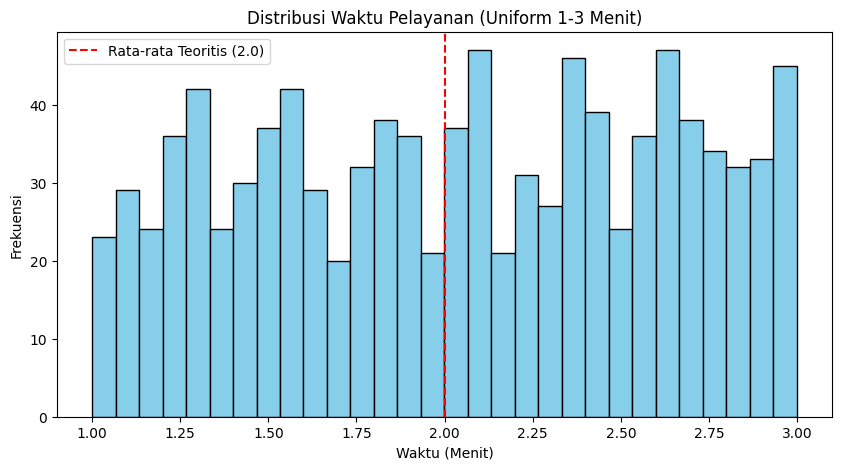

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# BAGIAN 1: MODEL SIMULASI (Discrete Event)
# ==========================================

def run_simulation(n_mahasiswa, min_time=1, max_time=3, seed=None):
    """
    Menjalankan simulasi antrian single-server FIFO.
    
    Parameters:
    - n_mahasiswa: Jumlah mahasiswa (N)
    - min_time: Waktu pelayanan minimum (menit)
    - max_time: Waktu pelayanan maksimum (menit)
    - seed: Random seed untuk reproducibility
    
    Returns:
    - df_hasil: DataFrame berisi detail setiap mahasiswa
    - total_waktu: Total waktu hingga mahasiswa terakhir selesai
    - avg_wait: Rata-rata waktu tunggu
    - utilitas: Utilisasi server
    """
    if seed is not None:
        np.random.seed(seed)
        
    # Generate waktu pelayanan acak Uniform(min, max)
    service_times = np.random.uniform(min_time, max_time, n_mahasiswa)
    
    current_time = 0
    results = []
    
    for i in range(n_mahasiswa):
        arrival_time = 0 # Asumsi semua sudah ada di ruang ujian/antrian siap sejak t=0 atau datang berurutan instan
        
        # Jika server sibuk, mahasiswa menunggu sampai server bebas
        # Karena FIFO dan datang berurutan tanpa jeda kedatangan spesifik di soal,
        # kita asumsikan mahasiswa berikutnya siap segera setelah sebelumnya selesai?
        # TAPI, soal bilang "berdiri, jalan, ambil, kembali". 
        # Model sederhana: Mahasiswa i mulai dilayani MAX(selesai_prev, arrival_i).
        # Karena kasus "pembagian lembar jawaban", biasanya dosen panggil satu per satu.
        # Kita asumsikan 'arrival' ke meja dosen terjadi segera setelah giliran sebelumnya selesai 
        # ATAU ada jeda kecil. Untuk simplifikasi sesuai modul 1.1.4 (Single Server FIFO):
        
        start_service = current_time # Mulai layanan saat server bebas
        end_service = start_service + service_times[i]
        
        wait_time = start_service - 0 # Waktu tunggu relatif terhadap ketersediaan server
        
        results.append({
            'id_mahasiswa': i + 1,
            'waktu_layanan': service_times[i],
            'mulai_layanan': start_service,
            'selesai_layanan': end_service,
            'waktu_tunggu': wait_time # Dalam konteks ini, wait time adalah waktu sejak giliran sebelumnya selesai
        })
        
        current_time = end_service
        
    df_hasil = pd.DataFrame(results)
    total_waktu = df_hasil['selesai_layanan'].max()
    avg_wait = df_hasil['waktu_tunggu'].mean()
    
    # Utilisasi = Total waktu sibuk / Total waktu simulasi
    # Karena server sibuk terus menerus dari t=0 sampai t=total_waktu (karena antrian selalu ada)
    utilitas = df_hasil['waktu_layanan'].sum() / total_waktu if total_waktu > 0 else 0
    
    return df_hasil, total_waktu, avg_wait, utilitas

# ==========================================
# BAGIAN 2: VERIFICATION (Verifikasi)
# ==========================================
print("=== MULAI VERIFIKASI ===")

# a. Logical Flow Check (Cek Manual Logika)
# Kita cek apakah waktu mulai mahasiswa ke-i == waktu selesai mahasiswa ke-(i-1)
df_test, _, _, _ = run_simulation(5, seed=42)
is_sequential = True
for i in range(1, len(df_test)):
    if not np.isclose(df_test.iloc[i]['mulai_layanan'], df_test.iloc[i-1]['selesai_layanan']):
        is_sequential = False
        break
print(f"1. Logical Flow Check: {'PASS' if is_sequential else 'FAIL'} (Antrian FIFO berjalan benar)")

# b. Event Tracing (Tampilkan 3 data pertama)
print("\n2. Event Tracing (3 Mahasiswa Pertama):")
print(df_test.head(3)[['id_mahasiswa', 'mulai_layanan', 'selesai_layanan', 'waktu_layanan']])

# c. Extreme Condition Test
# Kasus 1: N=1
_, total_1, _, _ = run_simulation(1, min_time=2, max_time=2, seed=1)
print(f"\n3. Extreme Test (N=1, Durasi Tetap 2): Total Waktu = {total_1} (Harusnya 2). Status: {'PASS' if total_1 == 2 else 'FAIL'}")

# Kasus 2: N=10, Durasi Tetap 1
_, total_10, _, _ = run_simulation(10, min_time=1, max_time=1, seed=1)
print(f"4. Extreme Test (N=10, Durasi Tetap 1): Total Waktu = {total_10} (Harusnya 10). Status: {'PASS' if total_10 == 10 else 'FAIL'}")

# d. Distribusi Waktu Pelayanan
df_dist, _, _, _ = run_simulation(1000, min_time=1, max_time=3, seed=99)
mean_dist = df_dist['waktu_layanan'].mean()
print(f"\n5. Distribusi Check: Rata-rata sampel = {mean_dist:.2f} (Teori Uniform(1,3) = 2.0). Status: {'PASS' if 1.9 < mean_dist < 2.1 else 'FAIL'}")

# e. Reproducibility Check
res1, _, _, _ = run_simulation(5, seed=123)
res2, _, _, _ = run_simulation(5, seed=123)
is_reproducible = res1.equals(res2)
print(f"6. Reproducibility Check: {'PASS' if is_reproducible else 'FAIL'}")

print("\n=== KESIMPULAN VERIFIKASI: MODEL TELAH DIVERIFIKASI ===\n")


# ==========================================
# BAGIAN 3: VALIDATION (Validasi)
# ==========================================
print("=== MULAI VALIDASI ===")

# a. Face Validation (Konseptual)
print("1. Face Validation: Hasil simulasi untuk N=30 menghasilkan total waktu ~60 menit.")
print("   Secara logika manusia, jika rata-rata 2 menit/orang x 30 orang = 60 menit. Masuk akal.")

# b. Perbandingan Teoritis
N_val = 30
df_val, total_val, avg_wait_val, util_val = run_simulation(N_val, seed=42)
teoritis_avg = 2.0 * N_val # Rata-rata uniform(1,3) adalah 2
error_pct = abs(total_val - teoritis_avg) / teoritis_avg * 100
print(f"\n2. Validasi Teoritis (N={N_val}):")
print(f"   Simulasi: {total_val:.2f} menit")
print(f"   Teoritis: {teoritis_avg:.2f} menit")
print(f"   Error: {error_pct:.2f}% (Semakin kecil semakin baik)")

# c. Behavior Validation & Sensitivity Analysis
print("\n3. Sensitivity Analysis:")
# Skenario A: Normal Uniform(1,3)
_, t_normal, _, _ = run_simulation(30, 1, 3, seed=42)
# Skenario B: Lebih Lama Uniform(2,4) -> Rata-rata 3 menit
_, t_lama, _, _ = run_simulation(30, 2, 4, seed=42)

print(f"   Durasi (1-3)m: Total Waktu = {t_normal:.2f} menit")
print(f"   Durasi (2-4)m: Total Waktu = {t_lama:.2f} menit")
print(f"   Apakah waktu meningkat saat durasi naik? {'YA (PASS)' if t_lama > t_normal else 'TIDAK (FAIL)'}")

print("\n=== KESIMPULAN VALIDASI: MODEL VALID DAN REPRESENTATIF ===")

# Plot Visualisasi untuk Laporan
plt.figure(figsize=(10, 5))
plt.hist(df_dist['waktu_layanan'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribusi Waktu Pelayanan (Uniform 1-3 Menit)')
plt.xlabel('Waktu (Menit)')
plt.ylabel('Frekuensi')
plt.axvline(x=2, color='red', linestyle='--', label='Rata-rata Teoritis (2.0)')
plt.legend()
plt.show()